left_eye_center_x            4309
left_eye_center_y            4309
right_eye_center_x           4306
right_eye_center_y           4306
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   4319
nose_tip_y                   4319
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    4289
mouth_center_b

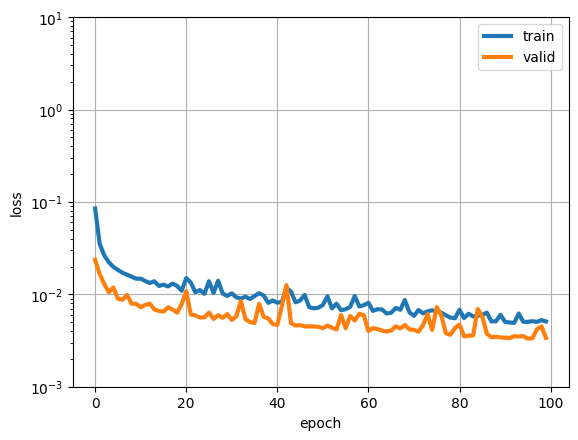

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os


# 資料路徑 Data Path
FTRAIN =  'training.csv'
FTEST =   'test.csv'
FLOOKUP = 'IdLookupTable.csv'

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

class Dataset(torch.utils.data.Dataset):
    def __init__(self, test=False, cols=None):
        fname = FTEST if test else FTRAIN
        self.test = test
        df = pd.read_csv(fname)

        # Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
        df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

        # 提取 特定欄位 相關的數據
        if cols:
            df = df[list(cols) + ['Image']]

        print(df.count()) # 資料集的筆數
        df = df.dropna()  # 刪除其中缺少值的資料

        self.X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
        self.X = self.X.astype(np.float32) # 轉換資料型態

        if not test: # 只有 FTRAIN 有目標的標籤(label)
            self.y = df[df.columns[:-1]].values
            self.y = (self.y - 48) / 48
            self.X, self.y = shuffle(self.X, self.y, random_state=42) # 對資料進行 洗牌
            self.y = self.y.astype(np.float32)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if not self.test:
            y = torch.tensor(self.y[idx],dtype=torch.float32)
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X,y
        else:
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X


class FCN(nn.Module):

    def __init__(self, num_classes = 30):
        super(FCN, self).__init__()
        self.fc1 = nn.Linear(9216, 100)
        self.bn1 = nn.BatchNorm1d(100)
        self.fc2 = nn.Linear(100, 30)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train(device,train_loader, model, criterion, optimizer):
    losses = AverageMeter()

    model.train()

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # compute output

        output = model(input)
        loss = criterion(output, target)

        losses.update(loss.item(), input.size(0))

        # compute gradient and do optimizing step

        loss.backward()
        optimizer.step()

    log = OrderedDict([('loss', losses.avg),])

    return log

def validate(device,train_loader, model, criterion):
    losses = AverageMeter()

    model.eval()
    with torch.no_grad():
        for i, (input, target) in enumerate(train_loader):
            input = input.to(device)
            target = target.to(device)

            # compute output

            output = model(input)
            loss = criterion(output, target)


            losses.update(loss.item(), input.size(0))


    log = OrderedDict([('loss', losses.avg),])

    return log

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=args.lr)

model = FCN().to(device)
model = nn.DataParallel(model)
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.01,
            momentum=0.9, nesterov=True)
criterion = nn.MSELoss().to(device)
epochs = 100
dataset = Dataset()
dataSize = len(dataset)
indices = list(range(dataSize))
split = int(np.floor(0.2 * dataSize))
train_idx , val_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
train_loader = DataLoader(dataset, batch_size=128, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=128, sampler=val_sampler)
train_log = list()
val_log = list()
for epoch in range(epochs):
    train_log.append(train(device, train_loader,model,criterion,optimizer)['loss'])
    val_log.append(validate(device, val_loader,model,criterion)['loss'])
    print("Epoch:{}/{} Train:{:.5f}\tval:{:.5f}\n".format(epoch + 1 ,epochs, train_log[-1], val_log[-1]))

torch.save(model, os.path.join('model_faceKeyPoint_'+ str(epochs) + '.pt'))
loss = train_log
val_loss = val_log

plt.plot(loss, linewidth=3, label='train')
plt.plot(val_loss, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim(1e-3, 1e+1)
plt.yscale('log')
plt.show()

ImageId    1783
Image      1783
dtype: int64


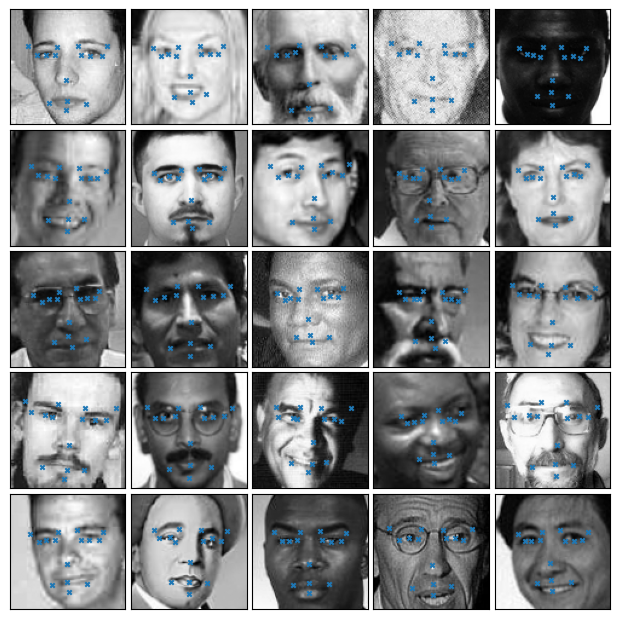

In [4]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)
    axis.imshow(img, cmap='gray')
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

testset = Dataset(test=True)

test_loader = DataLoader(testset, batch_size=128)
model.eval()
input = None
y_pred = None
with torch.no_grad():
    for i, (input) in enumerate(test_loader):
        input = input.to(device)
        y_pred = model(input).cpu().numpy()
        input = input.cpu().numpy()


fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    plot_sample (input[i], y_pred[i], ax)

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

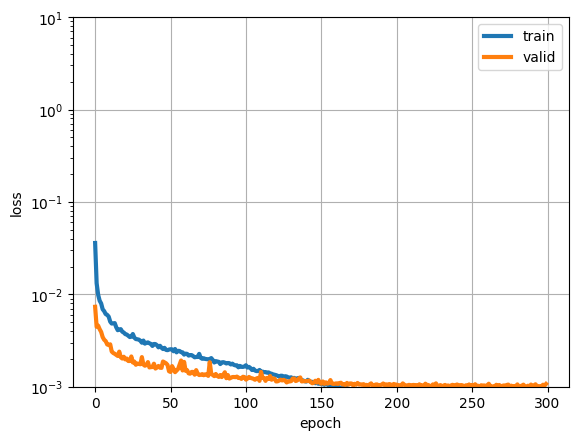

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os
epochs = 300
class cnn_model(nn.Module):

    def __init__(self):
        super().__init__()

        # 卷積層 (Conv Blocks)
        # 輸入: 1x96x96
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2) # 輸出: 32x48x48

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2) # 輸出: 64x24x24

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2) # 輸出: 128x12x12

        # 全連接層 (Fully Connected Layers)
        # 壓平後輸入大小: 128 * 12 * 12 = 18432
        self.fc1 = nn.Linear(128 * 12 * 12, 500)
        self.fc2 = nn.Linear(500, 30) # 輸出 30 個標記點

        # **新增：加入 Dropout 以減少過度擬合**
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))

        # 壓平 (Flatten)
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x) # 應用 Dropout
        x = self.fc2(x)

        return x

class Dataset2d(torch.utils.data.Dataset):
    def __init__(self, test=False, cols=None):
        fname = FTEST if test else FTRAIN
        self.test = test
        df = pd.read_csv(fname)

        # Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
        df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

        # 提取 特定欄位 相關的數據
        if cols:
            df = df[list(cols) + ['Image']]

        print(df.count()) # 資料集的筆數
        df = df.dropna()  # 刪除其中缺少值的資料

        self.X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
        self.X = self.X.astype(np.float32) # 轉換資料型態

        if not test: # 只有 FTRAIN 有目標的標籤(label)
            self.y = df[df.columns[:-1]].values
            self.y = (self.y - 48) / 48
            self.X, self.y = shuffle(self.X, self.y, random_state=42) # 對資料進行 洗牌
            self.y = self.y.astype(np.float32)
        else:
            self.y = None
        #self.X = self.X.reshape(-1, 1, 96, 96)
        self.X = self.X.reshape(-1, 96, 96, 1) # 轉換成 Conv2D的卷積層 的 input shape
        self.X = self.X.transpose((0,3,1,2))
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if not self.test:
            y = torch.tensor(self.y[idx],dtype=torch.float32)
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X,y
        else:
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X

def train(device,train_loader, model, criterion, optimizer):
    losses = AverageMeter()

    model.train()

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # compute output

        output = model(input)
        loss = criterion(output, target)

        losses.update(loss.item(), input.size(0))

        # compute gradient and do optimizing step

        loss.backward()
        optimizer.step()

    log = OrderedDict([('loss', losses.avg),])

    return log

def validate(device,train_loader, model, criterion):
    losses = AverageMeter()

    model.eval()
    with torch.no_grad():
        for i, (input, target) in enumerate(train_loader):
            input = input.to(device)
            target = target.to(device)

            # compute output

            output = model(input)
            loss = criterion(output, target)


            losses.update(loss.item(), input.size(0))


    log = OrderedDict([('loss', losses.avg),])

    return log


model2 = cnn_model().to(device)
model2 = nn.DataParallel(model2)
dataset = Dataset2d()
dataSize = len(dataset)
indices = list(range(dataSize))
split = int(np.floor(0.2 * dataSize))
train_idx , val_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
train_loader = DataLoader(dataset, batch_size=64, sampler=train_sampler)#64
val_loader = DataLoader(dataset, batch_size=64, sampler=val_sampler)
train_log = list()
val_log = list()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.0005)#0.0005
#optimizer = optim.SGD(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.01,momentum=0.9, nesterov=True)
criterion = nn.MSELoss().to(device)

for epoch in range(epochs):
    train_log.append(train(device, train_loader,model2,criterion,optimizer)['loss'])
    val_log.append(validate(device, val_loader,model2,criterion)['loss'])
    print("Epoch:{}/{} Train:{:.5f}\tval:{:.5f}\n".format(epoch + 1 ,epochs, train_log[-1], val_log[-1]))

torch.save(model2, os.path.join('model2_faceKeyPoint_'+ str(epochs) + '.pt'))
loss = train_log
val_loss = val_log

plt.plot(loss, linewidth=3, label='train')
plt.plot(val_loss, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim(1e-3, 1e+1)
plt.yscale('log')
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os


FTRAIN =  'training.csv'
FTEST =   'test.csv'
FLOOKUP = 'IdLookupTable.csv'
fname =  FTEST

df = pd.read_csv(fname)

# Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

# 提取 特定欄位 相關的數據
#print(df.count()) # 資料集的筆數
df = df.dropna()  # 刪除其中缺少值的資料

X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
X = X.astype(np.float32) # 轉換資料型態
print(X)


[[0.7137255  0.7176471  0.7137255  ... 0.03137255 0.01960784 0.01960784]
 [0.29803923 0.34117648 0.31764707 ... 0.89411765 0.827451   0.65882355]
 [0.69411767 0.6901961  0.68235296 ... 0.00392157 0.00392157 0.00392157]
 ...
 [0.10980392 0.10980392 0.11372549 ... 0.3019608  0.30588236 0.30588236]
 [0.40784314 0.37254903 0.2784314  ... 0.5647059  0.5921569  0.62352943]
 [0.24705882 0.23921569 0.2509804  ... 0.44313726 0.4392157  0.44313726]]


ImageId    1783
Image      1783
dtype: int64


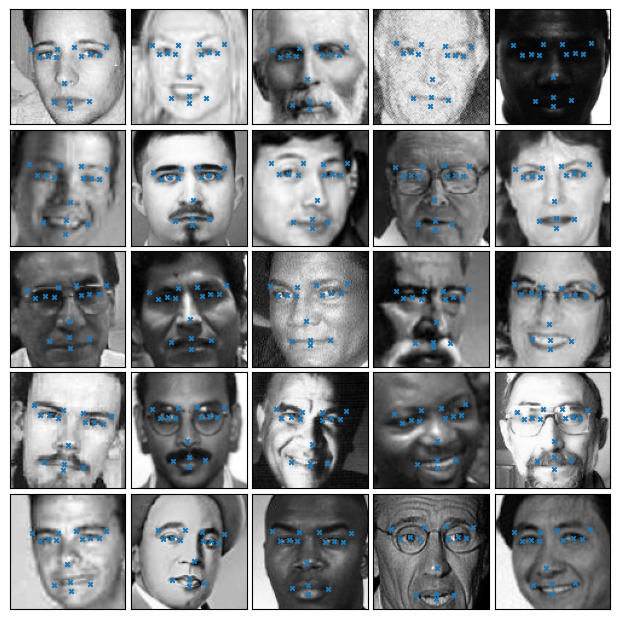

In [9]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)
    axis.imshow(img, cmap='gray')
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

testset = Dataset2d(test=True)

test_loader = DataLoader(testset, batch_size=128)
model.eval()
input = None
y_pred2 = None
with torch.no_grad():
    for i, (input) in enumerate(test_loader):
        input = input.to(device)
        y_pred2 = model2(input).cpu().numpy()
        input = input.cpu().numpy()


fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    plot_sample (input[i], y_pred2[i], ax)

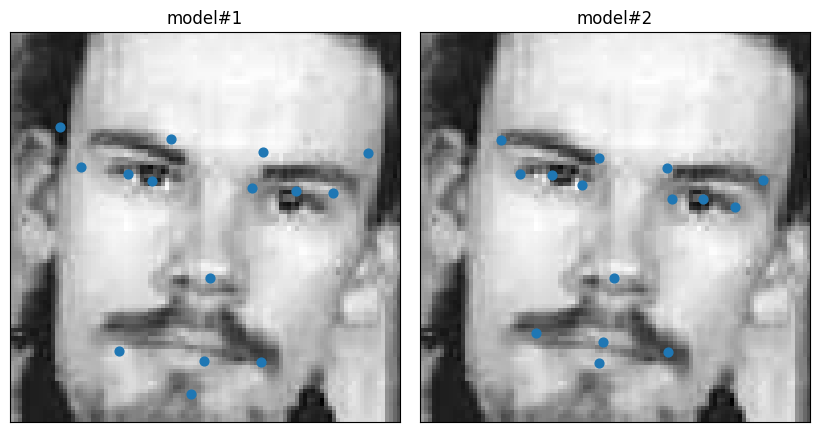

In [10]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)       # 圖像是 96x96
    axis.imshow(img, cmap='gray') # 以灰階來顯示

    # 模型預測出來的 15個臉部關鍵點 列印在圖像上
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='o', s=40)

fig = plt.figure(figsize=(8, 8))

idx = 15 # 找一張圖像 來比較兩個模型 預測的結果

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# 第一個 模型

ax = fig.add_subplot(1, 2, 1, xticks=[], yticks=[])
ax.set_title('model#1')
plot_sample(input[idx], y_pred[idx], ax)

# 第二個 模型
ax = fig.add_subplot(1, 2, 2, xticks=[], yticks=[])
ax.set_title('model#2')
plot_sample(input[idx], y_pred2[idx], ax)

plt.show()